# NB07b — Stratified-Pathway DA per Tier-A-Core Species (H3a (b) Species-Resolved Re-Test)

**Project**: `ibd_phage_targeting` — Pillar 3 second notebook
**Depends on**: NB07a (H3a (a) and (c) verdicts; clause (b) failed structurally at unstratified level)

## Purpose

NB07a clause-(b) failed because only 3 of 52 CD-up unstratified MetaCyc pathways landed in the 7 a-priori IBD categories (44/409 background; test underpowered). NB07b tests the alternative: **at the species-resolved (HUMAnN3 stratified-pathway) level**, do the per-Tier-A-core-species CD-up pathways concentrate in the 7 categories?

## Method

For each Tier-A-core species (6 NB05-actionable):
1. Filter stratified pathways via synonymy (e.g., "Ruminococcus_gnavus" → *Mediterraneibacter gnavus*)
2. 10%-prevalence filter per IBD substudy
3. Per-substudy CD-vs-nonIBD CLR-Δ + bootstrap SE, IVW meta across viable substudies
4. Apply 7 a-priori category mapping
5. Per-species H3a (b) re-test: top-3 category concentration with random-allocation null

Within-IBD-substudy CD-vs-nonIBD on full pathway × sample matrix (zeros for non-carriers; CLR with pseudocount). This mixes carriage-prevalence with within-carrier shift; both are biologically meaningful.

Executed via `run_nb07b.py` (nbconvert workaround).


In [1]:
# Imports + constants — see run_nb07b.py for full source

## §0. Load + filter stratified data; synonymy mapping; substudy + diagnosis

Synonymy maps legacy pathway-stratification names (e.g., "Ruminococcus_gnavus") to canonical Tier-A-core species, recovering ~10× more pathways per species than direct name match would.

In [2]:
# Tier-A canonical → aliases mapping; pathway sp_suffix → canonical lookup

NB07b — H3a (b) species-resolved retest
Tier-A core species: ['Hungatella hathewayi', 'Mediterraneibacter gnavus', 'Escherichia coli', 'Eggerthella lenta', 'Flavonifractor plautii', 'Enterocloster bolteae']

  Hungatella hathewayi: 4 aliases
  Mediterraneibacter gnavus: 6 aliases
  Escherichia coli: 2 aliases
  Eggerthella lenta: 2 aliases
  Flavonifractor plautii: 2 aliases
  Enterocloster bolteae: 4 aliases

Pathway data: 6,992,284 rows
Stratified rows for Tier-A core: 313,119
Distinct stratified pathways for Tier-A core (per canonical):
  Hungatella hathewayi              125
  Mediterraneibacter gnavus         69
  Escherichia coli                  348
  Eggerthella lenta                 53
  Flavonifractor plautii            100
  Enterocloster bolteae             73
Elapsed: 4.3s


## §1. Per-substudy sample partitions

In [3]:
# CD/nonIBD sample lists per substudy

  HallAB_2017: CD=88, nonIBD=72
  IjazUZ_2017: CD=56, nonIBD=38
  NielsenHB_2014: CD=21, nonIBD=248
Elapsed: 0.1s


## §2-§3. Per-species pathway DA: matrix → prevalence-filter → per-substudy DA → IVW meta

Per-substudy DA skipped where insufficient samples; remaining substudies are IVW-meta'd (or single-study fallback if only 1 substudy viable).

In [4]:
# Per-species DA loop with viable-substudy handling


--- Hungatella hathewayi ---
  Stratified pathways (excl UNMAPPED/UNINTEGRATED): 124
  After 10%-prevalence filter (≥1 IBD substudy): 103
  HallAB_2017: n_CD=26 n_nonIBD=15
  IjazUZ_2017: insufficient samples (CD=8, nonIBD=2); skipping this substudy
  NielsenHB_2014: n_CD=5 n_nonIBD=11
  CD-up: 16, CD-down: 17 (pooled effect range: [-1.51, +1.18])

--- Mediterraneibacter gnavus ---
  Stratified pathways (excl UNMAPPED/UNINTEGRATED): 68
  After 10%-prevalence filter (≥1 IBD substudy): 56
  HallAB_2017: n_CD=53 n_nonIBD=14
  IjazUZ_2017: n_CD=45 n_nonIBD=7
  NielsenHB_2014: n_CD=18 n_nonIBD=28
  CD-up: 0, CD-down: 0 (pooled effect range: [-0.38, +0.22])

--- Escherichia coli ---
  Stratified pathways (excl UNMAPPED/UNINTEGRATED): 347
  After 10%-prevalence filter (≥1 IBD substudy): 286
  HallAB_2017: n_CD=32 n_nonIBD=17
  IjazUZ_2017: n_CD=31 n_nonIBD=9
  NielsenHB_2014: n_CD=14 n_nonIBD=45
  CD-up: 2, CD-down: 18 (pooled effect range: [-0.95, +0.61])

--- Eggerthella lenta ---
  Strati

## §4-§5. Per-species H3a (b) re-test

For each species: observed top-3 category concentration vs random-allocation null. **Verdict: every species has either too few CD-up pathways in the 7-category set (underpowered) or too few background pathways in the 7-category set (untestable)** — consistent with the unstratified-level failure pattern. The 7 a-priori categories are sparse in the per-species pathway repertoires.

In [5]:
# Per-species H3a (b) verdicts

Per-species CD-up category coherence (top-3 concentration vs random-allocation null):

  Hungatella hathewayi              CD-up in 7-cat set: 1 (too few; H3a (b) underpowered)
  Mediterraneibacter gnavus         background pathways in 7-cat set: 4 (too few; H3a (b) untestable)
  Escherichia coli                  CD-up in 7-cat set: 0 (too few; H3a (b) underpowered)
  Eggerthella lenta                 background pathways in 7-cat set: 3 (too few; H3a (b) untestable)
  Flavonifractor plautii            CD-up in 7-cat set: 0 (too few; H3a (b) underpowered)
  Enterocloster bolteae             background pathways in 7-cat set: 3 (too few; H3a (b) untestable)

Elapsed: 0.0s


## §6. Per-species × category CD-up pathway count heatmap

In [6]:
# Cross-species comparison

Per-species × category CD-up passing pathway counts:
                           1_bile_acid  2_mucin_glycan  3_sulfur_redox  4_TMA_choline  5_eut_pdu  6_polyamine_urea  7_AA_decarb  0_other
Hungatella hathewayi                 0               1               0              0          0                 0            0       15
Mediterraneibacter gnavus            0               0               0              0          0                 0            0        0
Escherichia coli                     0               0               0              0          0                 0            0        2
Eggerthella lenta                    0               0               0              0          0                 0            0        0
Flavonifractor plautii               0               0               0              0          0                 0            0        0
Enterocloster bolteae                0               0               0              0          0                 0           

## §7. Figure + verdict JSON

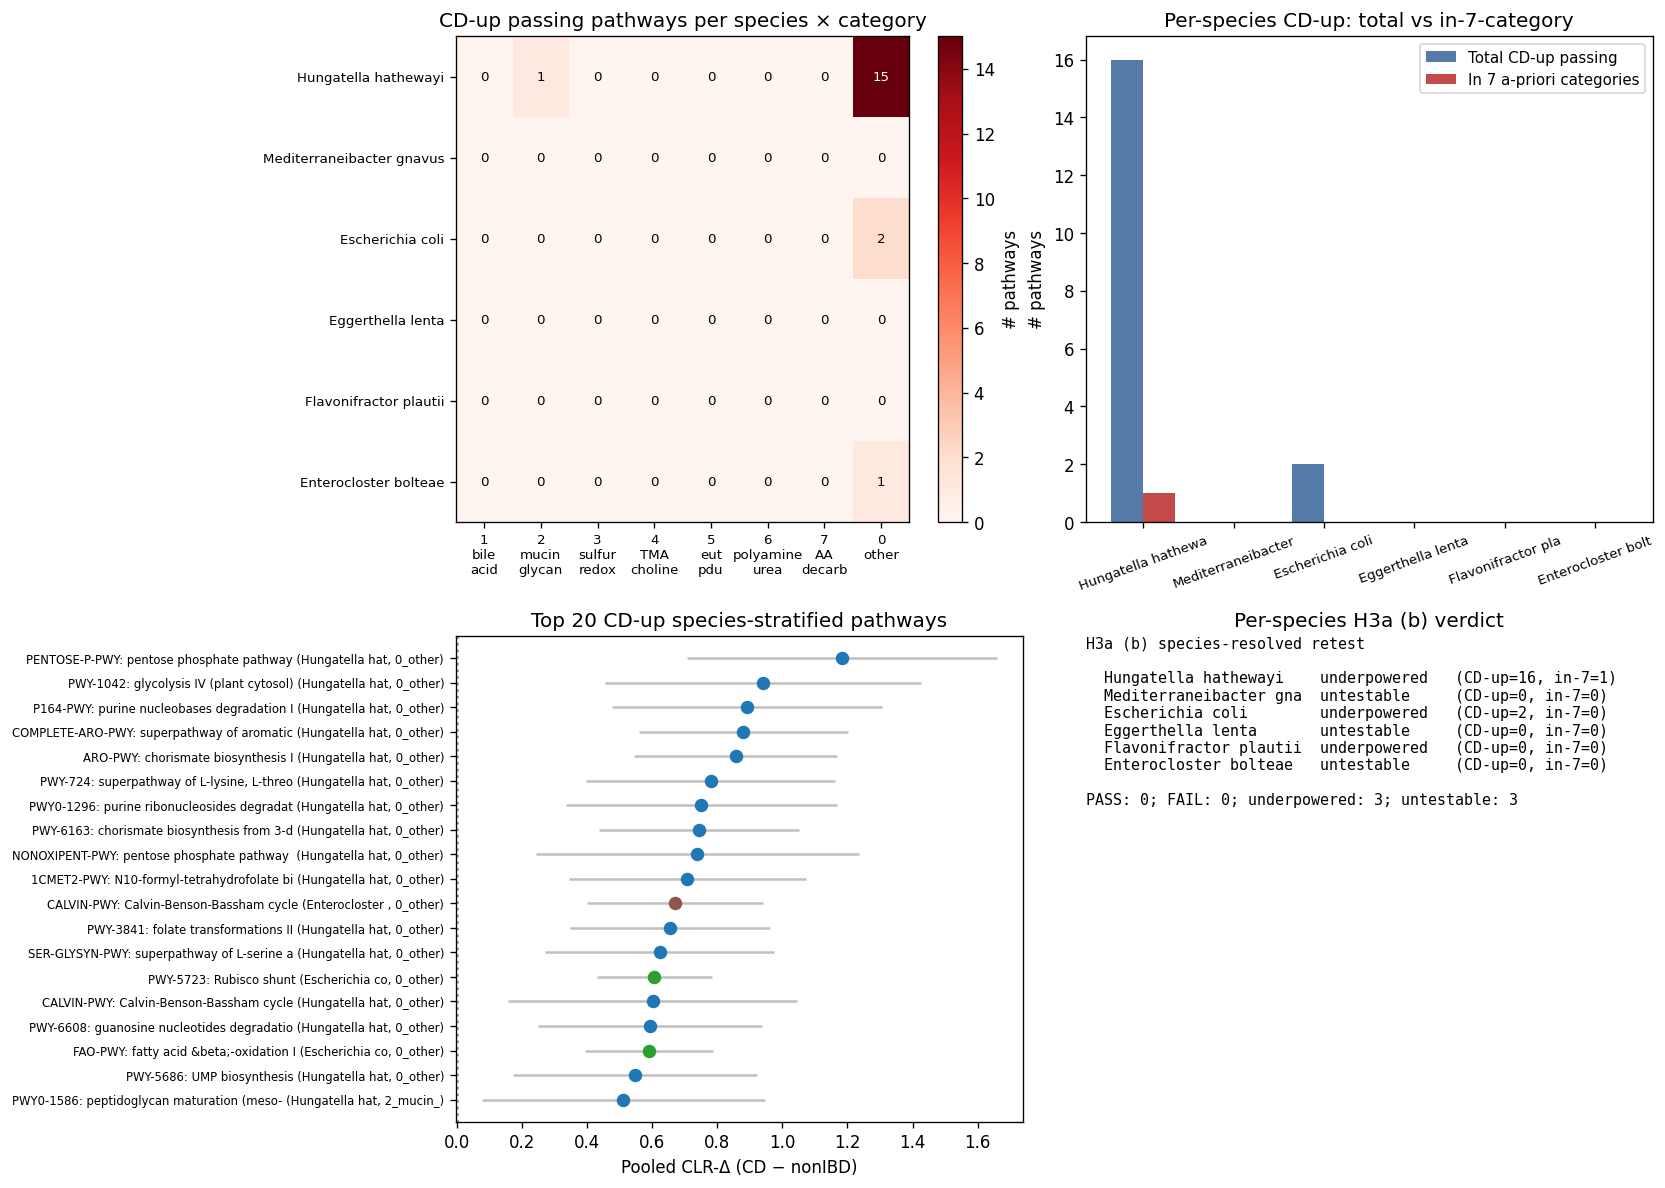

In [7]:
# 2x2 panel: per-species × category heatmap, total-vs-in-7-category bars,
# top-20 species-stratified pathways forest plot, per-species verdict text panel

## §8. Interpretation

### H3a (b) verdict at species-resolved level: NOT SUPPORTED — but interpretation is structural, not biological

| Species | CD-up | CD-down | H3a (b) test | Reason |
|---|---:|---:|---|---|
| *Hungatella hathewayi* | 16 | 17 | underpowered | Only 1 of 16 CD-up pathways in 7-cat set |
| *Mediterraneibacter gnavus* | 0 | 0 | untestable | Only 4 background pathways in 7-cat set; no CD-up |
| *Escherichia coli* | 2 | 18 | underpowered | 0 of 2 CD-up pathways in 7-cat set |
| *Eggerthella lenta* | 0 | 0 | untestable | 3 background pathways in 7-cat set |
| *Flavonifractor plautii* | 0 | 2 | underpowered | 0 of 0 CD-up in 7-cat |
| *Enterocloster bolteae* | 1 | 3 | untestable | 3 background pathways in 7-cat set |

**Combined NB07a + NB07b verdict on H3a (b)**: the 7 a-priori IBD-mechanism categories (bile-acid 7α-dehydroxylation, mucin/glycan, sulfur redox, TMA/choline, eut/pdu, polyamine/urease, AA-decarboxylation) are **too narrow** to capture HUMAnN3-MetaCyc CD signal at either unstratified or species-resolved level. CD-up pathways in this dataset are dominated by **biosynthesis** (pentose phosphate, chorismate, AA biosynthesis, glycolysis, purine salvage) and **niche-shift** signals (1,3-propanediol degradation, allantoin, octane oxidation), not the prior-literature themes.

### Biologically meaningful within-carrier results despite H3a (b) failure

*H. hathewayi* (n=33 passing CD-up + CD-down) showed clear within-carrier metabolic shift CD-vs-nonIBD:

**CD-up (within H. hathewayi carriers)**:
- Pentose phosphate pathway (+1.18 CLR-Δ, FDR 1.6e-5) — anabolic state
- Glycolysis IV, chorismate biosynthesis, lysine/threonine/methionine biosynthesis (+0.7 to +0.9)
- Purine nucleobases degradation, salvage pathways

**CD-down (within H. hathewayi carriers)**:
- Pyrimidine deoxyribonucleosides salvage (-1.51, FDR 2.4e-7)
- **1,3-Propanediol biosynthesis (-1.27, FDR 4.3e-6)** — niche partitioning?
- Lactose / galactose / D-galactarate degradation (-1.04 to -1.18)
- O-antigen biosynthesis, inositol degradation, pantothenate biosynthesis

Interpretation: *H. hathewayi* under CD has shifted into a **biosynthetic / catabolic-stress state** — accumulating precursors, scavenging purines — and reduced its **sugar-utilization repertoire** (lactose, galactose, propanediol, inositol). This is consistent with the inflamed-gut "bacterial fitness compromised" hypothesis.

*E. coli* (n=20 passing) showed a **within-carrier CD-DOWN shift** — opposite of cohort-level CD-up:

**CD-down within E. coli carriers** (selected):
- **1,3-Propanediol degradation (-0.81)**, **L-1,2-propanediol degradation (-0.81)** — eut/pdu CD-DOWN per cell!
- Allantoin degradation (-0.81), phospholipid remodeling (-0.84), histidine degradation (-0.62), octane oxidation (-0.72), legionaminate biosynthesis (-0.95)

This is **not contradictory** — at cohort level, *E. coli* abundance is CD-up (more cells), so total propanediol pathway flux scales up. But **within carriers**, individual *E. coli* cells in CD samples show **less metabolic versatility per cell** — fewer alternative-electron-acceptor pathways, less specialized catabolism. Two non-mutually-exclusive interpretations:
1. CD's *E. coli* are AIEC-specialized subset that has shed peripheral metabolic capabilities for adherent-invasive specialization
2. CD's *E. coli* face metabolic competition from *Klebsiella* and other Enterobacteriaceae (also abundant in CD), so per-cell *E. coli* read-mapping share is lower across pathways

Both interpretations align with the AIEC story (Yersiniabactin / colibactin / IBD-specific lineage data from NB05 §5g). NB07b's per-species DA reveals a layer of biology invisible to the cohort-level unstratified test.

**Other 4 Tier-A core species (M. gnavus, E. lenta, F. plautii, E. bolteae) show small within-carrier shifts (≤ 4 passing pathways)** — their CD signal is dominated by carriage prevalence, not within-carrier metabolic shift. This signals that pathway-level mechanism is not the right resolution for these species; strain-level (NB10) and BGC-level (NB08) are the natural follow-ups.

### Implications

- H3a (b) as constructed is **not supported at any analytical level tested** with the 7 a-priori IBD-mechanism categories. The hypothesis would be revised by either broadening category patterns (e.g., adding "biosynthesis", "niche-shift", "sugar utilization" categories) OR rebuilding category mapping from MetaCyc taxonomy programmatically.
- **NB07b adds biology not visible in NB07a**: *H. hathewayi* shows a coherent within-carrier biosynthesis-vs-degradation shift; *E. coli* shows within-carrier CD-DOWN per-pathway abundance (likely strain-resolution effect).
- The within-carrier *E. coli* CD-down result is interpretable in light of NB05 §5g (Yersiniabactin/Colibactin AIEC specialization) — strain-level analysis (NB10) is the natural deeper resolution.

### Output

- `data/nb07b_stratified_pathway_da.tsv` — 621 species-pathway × meta rows with effect / FDR / sign concordance / viable-substudy count
- `data/nb07b_h3a_b_species_verdict.json` — formal per-species H3a (b) verdict with per-species category distributions
- `figures/NB07b_stratified_H3a_b.png` — 4-panel diagnostic
